# **Práctica sobre análisis de Fourier**

**Objetivos**

1. Analizar el comportamiento espectral de diferentes señales a partir del uso de herramientas de simulación como Python
2. Comprender el proceso de cálculo de la Transformada Discreta de Fourier (en Inglés, DFT)
3. Comprender el proceso de cálculo de la Transformada de Fourier de Tiempo Corto (en Inglés, STFT) como paso previo a la construcción de un espectrograma


# **Serie de Fourier**

Serie Compleja:

$$f(t) = \sum_{n=-∞}^{∞}{c_n e^{j2πnf_ot}}$$

$$c_n = \frac{1}{T_o}∫_{T_o}f(t)e^{-j2πnf_ot}dt $$

También existe la posibilidad de calcularla mediante los términos de la serie real:

$$f(t) = \frac{a_0}{2}+ \sum_{n=1}^{∞}a_ncos(nω_0t)+ \sum_{n=1}^{∞}b_nsin(nω_0t) $$

Coeficientes de la serie real:

$$a_0 = \frac{2}{T_0}∫_{T_0}f(t)dt, a_n=\frac{2}{T_0}∫_{T_0}f(t)cos(nω_0t)dt, b_n=\frac{2}{T_0}∫_{T_0}f(t)sin(nω_0t)dt$$

Relación entre coeficientes reales y complejos:

$$|c_n| = \sqrt{a_n^2 + b_n^2 }$$

Analice las funciones que se entregan a continuación, donde se calculan los N primeros coeficientes de la serie de Fourier para la señal de tren pulsado.

In [ ]:
from sympy import integrate, exp, symbols
import numpy as np
import matplotlib.pyplot as plt

def serie_fourier(Cn, N, T, f, fs, t):
    n_armonics = np.arange(-N,N+1,1)
    freq_spectrum = n_armonics*f
    #Compute n coeficients
    #Cn_eval = [np.fromiter([Cn.evalf(subs={n:i})], dtype=complex)[0]]

    f_t = 0
    Cn_eval = []
    for i in n_armonics:
        Cn_eval.append(np.abs(np.fromiter([Cn.evalf(subs={n:i})], dtype=complex)[0])) # "fromiter" convierte
        # los valores complejos simbólicos en complejos numéricos. Como genera lista, hay que evaluar el resultado
        # en la posición [0]
        armonic = np.fromiter([Cn.evalf(subs={n:i})], dtype=complex)*np.exp((1j*i*2*np.pi*f*t))
        f_t = f_t + armonic

    for i in n_armonics:
        if(i>=0):
           print("Freq = "+str((1/T)*i)+" Hz"+":"+" |c_"+str(i)+"| = "+str(Cn_eval[i+N]))

    plt.figure(figsize=(10,3))
    plt.subplot(121)
    plt.stem(freq_spectrum,np.asarray(Cn_eval)**2)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel('Potencia [lineal]')
    plt.title("Espectro")

    plt.subplot(122)
    plt.plot(t,f_t)
    plt.xlabel("Tiempo (s)")
    plt.ylabel('Amplitud')
    plt.title("Serie de Fourier N = "+str(N)+" Terminos")
    plt.grid()
    plt.show()

Freq = 0.0 Hz: |c_0| = 0.5
Freq = 1000.0 Hz: |c_1| = 0.3183098861837907
Freq = 2000.0 Hz: |c_2| = 1.949085916259688e-17
Freq = 3000.0 Hz: |c_3| = 0.1061032953945969


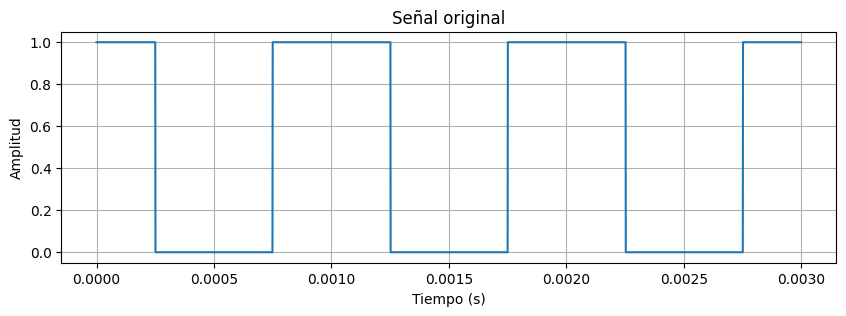

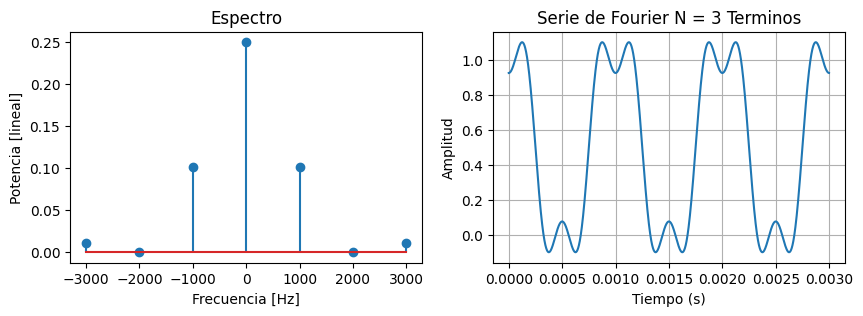

In [ ]:
f=1000
fs = 1e6 # fs para contruir el tren pulsado "continuo" en el computador
T=1/f
N_periods = 3
A=1
W0 = 2*np.pi*f # Frecuencia fundamental de la función

time_period = np.arange(0,T,1/fs)
ft_real_period = [A if 0 <= t <= T/4 or 3*T/4 <= t <= T else 0 for t in time_period]
time = np.arange(0,N_periods*T,1/fs)
#Graficar X cantidad de periodos de la señal
ft_real = np.hstack([ft_real_period for p in range(N_periods)])
plt.figure(figsize=(10,3))
plt.plot(time, ft_real[0:len(time)])
plt.xlabel("Tiempo (s)")
plt.ylabel('Amplitud')
plt.title("Señal original")
plt.grid()

n,t_simbol = symbols('n t_simbol')
N = 3 # N armónicos

Cn = (1/T)*integrate(A*exp(-(1j*W0*n*t_simbol)),(t_simbol,-T/4,T/4))

serie_fourier(Cn,N,T,f,fs, time)

In [ ]:
Cn

1000.0*Piecewise((-0.000159154943091895*I*exp(1.5707963267949*I*n)/n + 0.000159154943091895*I*exp(-1.5707963267949*I*n)/n, (n > -oo) & (n < oo) & Ne(n, 0)), (0.0005, True))

---
# **Laboratorio**
---

1. Para la señal (a) Diente de sierra unipolar con $T = 0.01$, y (b) triangular bipolar con $T = 0.01$, realice:

    * Identifique la potencia de cada armónico de las señales.

    * Reconstruya la señal en el tiempo usando los coeficientes de la serie de Fourier.

    * Grafique la serie de Fourier usando la función `plt.stem()` para mostrar cada uno de los armónicos y su frecuencia correspondiente.

2. Considere una señal de tren pulsado con frecuencia $1000$ Hz y ciclo de dureza del $50\%$. Calcule:

    * La potencia de la señal

    * La potencia de cada armónico

    * El número de componentes necesarios para alcanzar el 90% de la potencia

    * El ancho de banda

    * Modifice los parámetros de frecuencia y ciclo de dureza de la señal (Freq: 500Hz y 20000Hz; Duty: 25% y 75%. Las cuatro combinaciones) y concluya lo que se observa en el espectro resultante.

## **Construcción de un Espectrograma**

1. Usando una frecuencia de muestreo $f_s=512$ [muestras/segundo], genere las señales cosenonoidales $s_1$, $s_2$, $s_3$ y $s_4$ con frecuencias $16$ Hz, $32$ Hz, $64$ Hz y $128$ Hz, respectivamente, y $250$ ms de duración. Construya la señal $s$ concatenando horizontalmente las 4 señales. Realice el gráfico de la señal $s$ en el tiempo  

2. Utilice la función `np.fft.fft(señal)` para calcular la Transformada Discreta de Fourier (en Inglés, DFT) (usando el algorítmo Fast Fourier Transform, FFT) de las señales $s_1$, $s_2$, $s_3$ y $s_4$. Grafique las 4 transformadas en la misma figura tal que el eje vertical es la frecuencia y el eje horizontal es la magnitud.

    **Nota**: Solamente incluya las frecuencias positivas en el gráfico y normalice las transformadas de modo que solamente tome valores entre $0$ y $1$

3. La función `plt.imshow(matriz)` permite representar una matriz como una imagen donde el color de cada pixel está dado por el valor correspondiente en la matriz. Realice un subplot de 1x4. En cada eje utilice la función `plt.imshow(matriz)` para representar gráficamente la DFT de las señales $s_i$. Superponga en cada imagen, la DFT correspondiente como una función de frecuencia (graficada en el punto anterior)

4. El siguiente código ulitiza la función `plt.specgram` para graficar el espectrograma de una señal dada $s$.

In [ ]:
plt.specgram(s, Fs=fs, NFFT=128, noverlap=0, cmap='viridis', scale='linear')
# Títulos y etiquetas
plt.title('Espectrograma de la Señal')
plt.xlabel('Tiempo (s)')
plt.ylabel('Frecuencia (Hz)')
plt.colorbar(label='Intensidad (dB)')
plt.show()

* ¿Qué pasa si se elige NFFT $=128; 64; 100$? concluya.

* ¿Qué significa que el parámetro `noverlap` sea cero? utilice un valor diferente y concluya.

* ¿Por qué `noverlap` no puede ser mayor que NFFT?

## **Construcción de un Espectrograma 2**
Señal de audio.

1. Cargue la señal de audio `senal.wav`. Seleccione el segmento entre $18.75$ ms y $318.75$ ms ($300$ ms de duración). Reproduzca la señal y grafiquela en el tiempo y en frecuencia mediante su espectrograma usando la función `plt.spectrogram()`.


2. Divida la señal anterior en tres segmentos de $100$ ms cada uno y realice una aproximación al espectrograma usando la DFT de cada segmento del mismo modo que se realizó en el punto 2 de la sección "Construcción de un Espectrograma", donde se construyó "a mano" el concepto de espectrograma usando la función `plt.imshow`.

    * Dibuje el espectro de cada ventana sobre cada ventana (por ejemplo usando color rojo) de los espectrogramas calculados en el ítem anterior.

3. Usando la función `plt.spectrogram()` grafique en un sublpot de 4 espectrogramas del segmento de audio usando el mismo valor de NFFT, pero variando el parámetro `noverlap` de modo que haya 4 niveles de solapamiento incluyendo cero y un nivel alto de solapamiento, e.g., $[0\%, 25\%, 50\%, 80\%]$.
El $\%$ se toma respecto a la cantidad de puntos de una ventana. Se recomienda trabajar con ventanas de $25$ ms ($400$ muetras para $F_s=16000$).
